In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
from itertools import chain
from collections import Counter

# from simulator import Simulation
from tqdm.auto import tqdm
import itertools
import matplotlib as mpl
from collections import OrderedDict, defaultdict

from voting_mechanism_design.agents.pairwise_badgeholder import PairwiseBadgeholder, PairwiseBadgeholderPopulation
from voting_mechanism_design.projects.project import Project, ProjectPopulation
from voting_mechanism_design.funds_distribution.pairwise_binary import PairwiseBinary
from voting_mechanism_design.sim import RoundSimulation

from voting_mechanism_design.agents.quorum_badgeholder import QuorumBadgeholder, QuorumBadgeholderPopulation
from voting_mechanism_design.funds_distribution.threshold_and_aggregate import ThresholdAndAggregate

from voting_mechanism_design.mapping import mapping

import itertools
import numpy as np
import choix
import math

import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

from tqdm.auto import tqdm
from joblib import Parallel, delayed

warnings.simplefilter(action='ignore', category=UserWarning)
warnings.simplefilter(action="ignore", category=RuntimeWarning)

### Q+T Incentive Alignment

In [5]:
#Test simulation for incentive_alignment

def run_single_quorum_threshold_incentive_alignment_simulation(
        n_badgeholders=50,
        badgeholder_expertise_vec=None,
        badgeholder_laziness_vec=None,
        n_projects=100,
        project_impact_vec=None,
        # configuration specific to quorum+threshold voting method
        quorum=5,
        scoring_fn='mean',
        min_vote_amt=1,
        max_vote_amt=16,
        max_funding=100,
        random_seed=1234, 
        normalize = False, 
        vote_model = 'linear',
        funding_model = 'linear'
        #,misalignment_scale=100
    ):
    # create voters
    voters = []
    for ii in range(n_badgeholders):
        assert badgeholder_laziness_vec[ii] >= 0
        v = QuorumBadgeholder(
            badgeholder_id=ii,
            total_funds=max_funding,
            min_vote=min_vote_amt,  
            max_vote=max_vote_amt,
            laziness=badgeholder_laziness_vec[ii],
            expertise=badgeholder_expertise_vec[ii],
            coi_factor=0, 
            vote_model = vote_model
            #,expertise_model="k2"
        )
        voters.append(v)
    badgeholder_pop=QuorumBadgeholderPopulation()
    badgeholder_pop.add_badgeholders(voters)

    # add projects
    projects = []
    for ii in range(n_projects):
        p = Project(
            project_id=ii,
            true_impact=project_impact_vec[ii],  
            owner_id=None,  
        )
        projects.append(p)
    project_population = ProjectPopulation()
    project_population.add_projects(projects)

    # ##  Voting Simulation
    fund_distribution_model = ThresholdAndAggregate(
        scoring_method=scoring_fn,
        quorum=quorum,
        min_amount=0,
        normalize = normalize,
        funding_model = funding_model
    )
    simulation_obj = RoundSimulation(
        badgeholder_population=badgeholder_pop,
        projects=project_population,
        funding_design=fund_distribution_model,
        random_seed=random_seed
    )
    projects = project_population.get_projects()
    simulation_obj.run()

    projectid2score = simulation_obj.projectid2score

    projectid2funding = simulation_obj.projectid2funding
    projectid2score = OrderedDict(projectid2score) #a dictionary mapping project id to score
    ranks = np.argsort(np.asarray(list(projectid2funding.values()))) #a list of project id from lowest ranked to highest ranked
    
    return projectid2score, ranks, voters


In [6]:
# test w/ some random values to start for run_single_quorum_threshold_incentive_alignment_simulation
n_badgeholders = 25
n_projects = 100
badgeholder_expertise_vec = 0.25*np.ones(n_badgeholders)
badgeholder_laziness_vec = 0.25*np.ones(n_badgeholders)
project_impact_vec=np.linspace(0, 1, n_projects)  # enforce a strict ranking that we can compare against

quorum = 5
scoring_fn = 'mean'
min_vote_amt = 1
max_vote_amt = 100
max_funding = 40000
random_seed = 1234
normalize = False
voting_model = 'linear'
funding_model = 'linear'

qt_project2scores, qt_ranks_list, qt_voters = run_single_quorum_threshold_incentive_alignment_simulation(
        n_badgeholders=n_badgeholders,
        badgeholder_expertise_vec=badgeholder_expertise_vec,
        badgeholder_laziness_vec=badgeholder_laziness_vec,
        n_projects=n_projects,
        project_impact_vec=project_impact_vec,
        # configuration specific to quorum+threshold voting method
        quorum=quorum,
        scoring_fn=scoring_fn,
        min_vote_amt=min_vote_amt,
        max_vote_amt=max_vote_amt,
        max_funding=max_funding,
        random_seed=random_seed,
        normalize = False, 
        vote_model = voting_model,
        funding_model = funding_model
    )

In [7]:
print(sum(qt_project2scores.values()))

40000.0


Text(0, 0.5, 'Score')

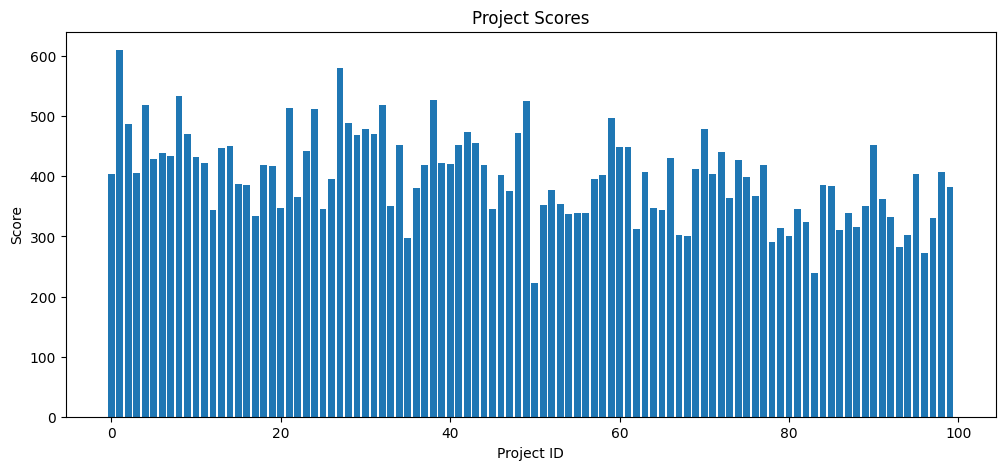

In [8]:
# plot
fig, ax = plt.subplots(1,1, figsize=(12,5))
axx = ax
axx.bar(qt_project2scores.keys(), qt_project2scores.values())
axx.set_title('Project Scores')
axx.set_xlabel('Project ID')  
axx.set_ylabel('Score')


In [9]:
# compute alignment between each voter and the outcome
alignment_dict = defaultdict(list)  # mapping of project to list of alignment scores
for project, project_score in qt_project2scores.items():
    for voter in qt_voters:
        vote_dict = voter.get_vote_dict()
        voter_score = vote_dict[project]
        delta_frac = abs(voter_score - project_score) / project_score
        alignment_dict[project].append(delta_frac)


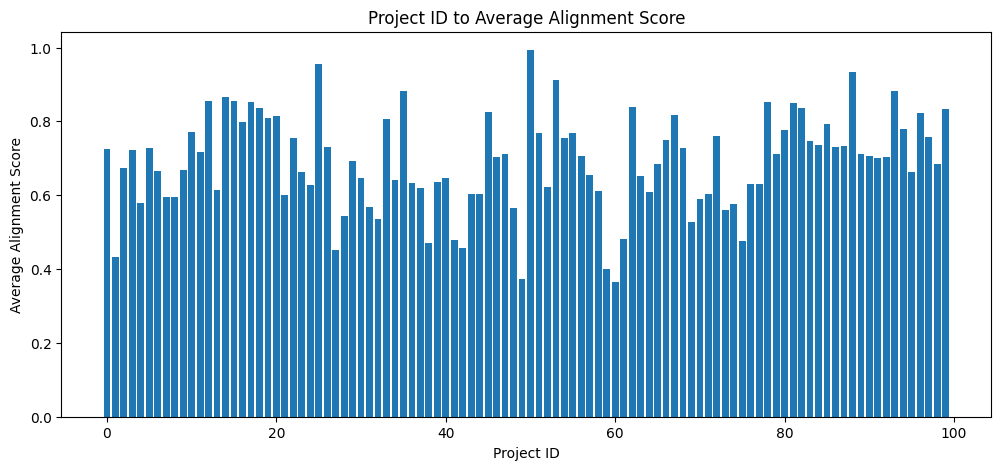

In [10]:
# plot the project id to the average alignment score
fig, ax = plt.subplots(1,1, figsize=(12,5))
axx = ax
axx.bar(alignment_dict.keys(), [np.mean(alignment_dict[project]) for project in alignment_dict.keys()])
axx.set_title('Project ID to Average Alignment Score')
axx.set_xlabel('Project ID')  
axx.set_ylabel('Average Alignment Score')
plt.show()

### Pairwise Incentive Alignment

In [19]:
def run_single_pairwise_simulation(
        n_badgeholders=50,
        badgeholder_expertise_vec=None,
        badgeholder_laziness_vec=None,
        n_projects=100,
        project_impact_vec=None,
        random_seed=1234
    ):
    # create badgeholders
    badgeholder_list = []
    for ii in range(n_badgeholders):
        badgeholder_id = ii
        expertise = badgeholder_expertise_vec[ii]
        laziness = badgeholder_laziness_vec[ii]
        
        coi_project_ids = []
        coi_factor = 0.0
        agent = PairwiseBadgeholder(
            badgeholder_id=badgeholder_id,
            voting_style='skewed_towards_impact',
            voting_style_kwargs={'use_impact_delta':False},
            expertise=expertise,
            laziness=laziness,
            coi_project_ix_vec=coi_project_ids,
            coi_factor=coi_factor,
        )
        badgeholder_list.append(agent)
    badgeholders = PairwiseBadgeholderPopulation()
    badgeholders.add_badgeholders(badgeholder_list)

    # create projects
    projects = []
    for ii in range(n_projects):
        project_id = ii
        project_impact = project_impact_vec[ii]
        project = Project(
            project_id=project_id,
            true_impact=project_impact,  
            owner_id=None,  # used for COI modeling
        )
        projects.append(project)
    project_population = ProjectPopulation()
    project_population.add_projects(projects)

    # this is a no-op currently, but can change in the future
    fund_distribution_model = PairwiseBinary()

    # create and run a simulation
    simulation_obj = RoundSimulation(
        badgeholder_population=badgeholders,
        projects=project_population,
        funding_design=fund_distribution_model,
        random_seed=random_seed
    )

    # voters can vote on all projects, but an individual badgeholder can decide to ignore
    # some, based on the badgeholder configuration
    voting_view_ix = list(itertools.combinations(range(project_population.num_projects), 2))  # we need a list since we use this twice
    voting_view = []
    for ix1, ix2 in voting_view_ix:
        voting_view.append((project_population.get_project(ix1), project_population.get_project(ix2)))
    simulation_obj.run(cast_votes_kwargs={'view': voting_view})

    # store the project impact differences
    # this is only for diagnostics/post-hoc analysis
    impact_diff_vec = []
    for ix1, ix2 in voting_view_ix:
        p1 = project_population.get_project(ix1)
        p2 = project_population.get_project(ix2)
        impact_diff_vec.append(p1.true_impact - p2.true_impact)

    # make a matrix of all the pairwise voting possibilities
    all_votes = simulation_obj.badgeholder_population.get_all_votes()
    project_list = simulation_obj.projects.projects
    N = len(project_list)
    project_vote_matrix = np.zeros((N, N))
    project2ix = {p:ix for ix, p in enumerate(project_list)}
    vote_data_list = []

    # put the votes into the format needed by the choix package
    for v in all_votes:
        ix1 = project2ix[v.project1]
        ix2 = project2ix[v.project2]
        project_vote_matrix[ix1, ix2] += v.val1
        project_vote_matrix[ix2, ix1] += v.val2

        if v.val1 > v.val2:
            vote_data_list.append((ix1, ix2))
        elif v.val2 > v.val1:
            vote_data_list.append((ix2, ix1))
        else:
            # TODO: not sure if there is a tie, is that even possible??
            print('In Tie scenario!')
            pass

    # estimate parameters of bradley terry model - TODO: update to MCMC estimation
    try:
        params = choix.ilsr_pairwise(N, vote_data_list)  
    except Exception as e:
        # print(f'Failed to estimate global rankings: {e}, adding some regularization!')
        params = choix.ilsr_pairwise(N, vote_data_list, alpha=0.01)
    # create rank order of project ids
    project_ix_worst_to_best_inferred = np.argsort(params)
    project_ix_best_to_worst_inferred = project_ix_worst_to_best_inferred[::-1]

    # # compare the inferred ranks to the actual ranks
    # actual_project_impacts = np.array([p.true_impact for p in project_list])
    # # rank them
    # project_ix_worst_to_best_actual = np.argsort(actual_project_impacts)
    # project_ix_best_to_worst_actual = project_ix_worst_to_best_actual[::-1]

    # return actual_project_impacts, project_ix_worst_to_best_inferred
    return params, project_ix_worst_to_best_inferred, impact_diff_vec, badgeholders

In [20]:
n_badgeholders = 25
n_projects = 100
badgeholder_expertise_vec = 0.25*np.ones(n_badgeholders)
badgeholder_laziness_vec = 0.25*np.ones(n_badgeholders)
project_impact_vec=np.linspace(0, 1, n_projects)  # enforce a strict ranking that we can compare against

quorum = 5
scoring_fn = 'mean'
min_vote_amt = 1
max_vote_amt = 16
max_funding = 100
random_seed = 1234

badgeholder_laziness_vec_pw = np.power(badgeholder_laziness_vec, 0.2)
pairwise_project_scores, pairwise_project_ranks, impact_diff_vec, pairwise_badgeholders = run_single_pairwise_simulation(
    n_badgeholders=n_badgeholders,
    badgeholder_expertise_vec=badgeholder_expertise_vec,
    badgeholder_laziness_vec=badgeholder_laziness_vec_pw,
    n_projects=n_projects,
    project_impact_vec=project_impact_vec,
    random_seed=random_seed
)

In [21]:
pairwise_project_ranks

array([ 4,  0,  7,  2,  5,  8, 11,  1,  3,  6, 16, 12, 15, 21, 17,  9, 33,
       22, 10, 25, 14, 18, 20, 13, 19, 26, 23, 27, 31, 42, 24, 28, 38, 35,
       37, 32, 39, 36, 34, 30, 29, 41, 43, 50, 46, 45, 49, 44, 40, 52, 55,
       48, 56, 53, 61, 54, 60, 47, 51, 63, 62, 64, 57, 68, 77, 72, 69, 67,
       59, 58, 78, 66, 75, 76, 82, 87, 79, 73, 71, 65, 81, 99, 84, 88, 74,
       70, 90, 83, 86, 93, 80, 89, 85, 96, 94, 97, 92, 91, 95, 98])

In [33]:
# need to run the choix estimation for each voter to get their individual ranking
vlist = pairwise_badgeholders.badgeholders[0].votes
vote_data_list = []
for v in vlist:
    ix1 = v.project1.project_id
    ix2 = v.project2.project_id
    if ix1 > ix2:
        vote_data_list.append((ix1, ix2))
    elif ix2 > ix1:
        vote_data_list.append((ix2, ix1))
    else:
        print('In Tie scenario!')
        pass

voter_ranking_params = choix.ilsr_pairwise(n_projects, vote_data_list, alpha=0.01)
voter_project_ix_worst_to_best_inferred = np.argsort(voter_ranking_params)

In [34]:
voter_project_ix_worst_to_best_inferred

array([ 0,  3,  1,  2,  4,  9,  5,  7, 10,  8,  6, 11, 17, 22, 12, 20, 15,
       21, 18, 13, 16, 23, 19, 14, 30, 26, 32, 29, 37, 27, 28, 33, 24, 36,
       34, 31, 35, 25, 41, 43, 38, 42, 44, 40, 51, 47, 46, 53, 39, 55, 45,
       49, 48, 50, 52, 70, 56, 57, 54, 60, 62, 67, 59, 61, 71, 69, 65, 64,
       66, 72, 83, 63, 58, 76, 74, 73, 77, 68, 75, 79, 78, 84, 87, 85, 81,
       80, 86, 82, 89, 92, 91, 88, 93, 90, 94, 97, 96, 95, 99, 98])

In [35]:
pairwise_project_ranks

array([ 4,  0,  7,  2,  5,  8, 11,  1,  3,  6, 16, 12, 15, 21, 17,  9, 33,
       22, 10, 25, 14, 18, 20, 13, 19, 26, 23, 27, 31, 42, 24, 28, 38, 35,
       37, 32, 39, 36, 34, 30, 29, 41, 43, 50, 46, 45, 49, 44, 40, 52, 55,
       48, 56, 53, 61, 54, 60, 47, 51, 63, 62, 64, 57, 68, 77, 72, 69, 67,
       59, 58, 78, 66, 75, 76, 82, 87, 79, 73, 71, 65, 81, 99, 84, 88, 74,
       70, 90, 83, 86, 93, 80, 89, 85, 96, 94, 97, 92, 91, 95, 98])

In [55]:
def distribute_funds(rankings, total_funds, method="linear", exponent=1.5):
    """
    Distribute funds based on project rankings using different methods.

    Args:
        rankings (array-like): Array of project rankings (0-based index).
        total_funds (float): Total amount of funds to distribute.
        method (str): Distribution method: 'linear', 'exponential', or 'power'.
        exponent (float): Exponent for the power law or exponential distribution (default 1.5).

    Returns:
        np.ndarray: Array of funds distributed to each project.
    """
    # Sort rankings to ensure proper ordering
    rankings = np.array(rankings)
    num_projects = len(rankings)
    
    # Compute weights based on the method
    if method == "linear":
        weights = np.arange(num_projects, 0, -1, dtype=float)  # Higher rank gets more
    elif method == "exponential":
        weights = np.exp(-np.arange(num_projects, dtype=float) / exponent)
    elif method == "power":
        weights = 1 / (np.arange(1, num_projects + 1, dtype=float) ** exponent)
    else:
        raise ValueError("Invalid method. Choose 'linear', 'exponential', or 'power'.")
    
    # Normalize weights to sum to 1
    weights /= np.sum(weights)
    
    # Distribute funds based on weights
    funds = weights * total_funds
    
    # Map funds to the original ranking order
    fund_distribution = np.zeros(num_projects)
    for i, rank in enumerate(rankings):
        fund_distribution[rank] = funds[i]
    
    return fund_distribution

In [65]:
kwargs = {
    'method': 'power', 
    'exponent': 0.1
}

actual_distribution = distribute_funds(
    pairwise_project_ranks, 
    40000, 
    **kwargs
)
voter_distribution = distribute_funds(
    voter_project_ix_worst_to_best_inferred, 
    40000, 
    **kwargs
)

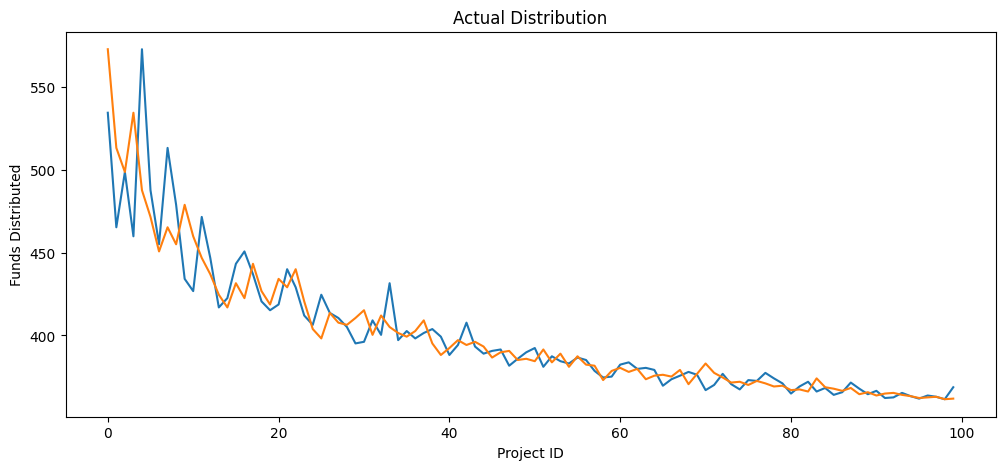

In [66]:
# plot the distributions
fig, ax = plt.subplots(1,1, figsize=(12,5))
axx = ax
axx.plot(np.arange(n_projects), actual_distribution)
axx.plot(np.arange(n_projects), voter_distribution)
axx.set_title('Actual Distribution')
axx.set_xlabel('Project ID')  
axx.set_ylabel('Funds Distributed')
plt.show()